---
title: "EDA: Elo Snapshots"
subtitle: "First dataset, first dead end - and why we ended up scraping full match histories"
author: "Miguel R."
date: today
---

This was the starting point of the project: a dataset of **Elo rating snapshots** for
the 48 qualified teams, taken at regular intervals leading up to the tournament. The
question of this notebook is simple: *is this dataset enough to predict matches?*

Spoiler from the conclusion: no, but the reasons why shaped the whole design of the
predictor.

## 1. Loading the snapshots


In [1]:
import pandas as pd
import pytest
from IPython.display import display

from colors import *

elo_df = pd.read_csv("./data/elo_ratings_wc2026.csv")
final_date = pd.to_datetime('2026-07-19')
# convert the column 'snapshot_date' to datetime'
elo_df["snapshot_date"] = pd.to_datetime(elo_df["snapshot_date"])
elo_df = elo_df[elo_df["snapshot_date"] <= final_date]
print(elo_df.info())
print(elo_df.describe())
teams = elo_df["country"].unique()

teams


<class 'pandas.DataFrame'>
Index: 4635 entries, 0 to 4682
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   year             4635 non-null   int64         
 1   snapshot_date    4635 non-null   datetime64[us]
 2   country          4635 non-null   str           
 3   rank             4635 non-null   int64         
 4   country_code     4635 non-null   str           
 5   rating           4635 non-null   int64         
 6   rank_max         4635 non-null   int64         
 7   rating_max       4635 non-null   int64         
 8   rank_avg         4635 non-null   int64         
 9   rating_avg       4635 non-null   int64         
 10  rank_min         4635 non-null   int64         
 11  rating_min       4635 non-null   int64         
 12  matches_total    4635 non-null   int64         
 13  matches_home     4635 non-null   int64         
 14  matches_away     4635 non-null   int64         
 15  mat

<StringArray>
[               'England',               'Scotland',              'Argentina',
                'Austria',                'Uruguay',                'Belgium',
                 'France',            'Netherlands',            'Switzerland',
           'South Africa',                'Germany',                 'Sweden',
                 'Norway',                 'Brazil',          'United States',
                  'Japan',               'Paraguay',                  'Spain',
                'Czechia',                  'Egypt',               'Portugal',
              'Australia',            'New Zealand',                 'Mexico',
                 'Turkey',                'Curaçao',                 'Canada',
                  'Haiti',                'Algeria',                'Tunisia',
               'Colombia',                'Ecuador',                 'Panama',
                'Croatia',                   'Iran',            'South Korea',
                   'Iraq',            

## 2. The twelve groups

The 2026 World Cup is the first with 48 teams, split into twelve groups of four. We
split the snapshots per group to see how competitive each group is on paper.


In [2]:
GROUP_A = ['Mexico', 'South Africa', 'South Korea', 'Czechia']
GROUP_B = ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland']
GROUP_C = ['Brazil', 'Morocco', 'Haiti', 'Scotland']
GROUP_D = ['United States', 'Paraguay', 'Australia', 'Turkey']
GROUP_E = ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador']
GROUP_F = ['Netherlands', 'Japan', 'Sweden', 'Tunisia']
GROUP_G = ['Belgium', 'Egypt', 'Iran', 'New Zealand']
GROUP_H = ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay']
GROUP_I = ['France', 'Senegal', 'Iraq', 'Norway']
GROUP_J = ['Argentina', 'Algeria', 'Austria', 'Jordan']
GROUP_K = ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia']
GROUP_L = ['England', 'Croatia', 'Ghana', 'Panama']


def check_groups(group: list) -> bool:
    not_founds = []
    for team in group:
        if not teams.__contains__(team):
            not_founds += team

    if not_founds:
        raise ValueError(f"{not_founds} {'is' if len(not_founds) == 1 else 'are'} not in the dataframe")
    else:
        return True


assert check_groups(GROUP_A)
assert check_groups(GROUP_B)
assert check_groups(GROUP_C)
assert check_groups(GROUP_D)
assert check_groups(GROUP_E)
assert check_groups(GROUP_F)
assert check_groups(GROUP_G)
assert check_groups(GROUP_H)
assert check_groups(GROUP_I)
assert check_groups(GROUP_J)
assert check_groups(GROUP_K)
assert check_groups(GROUP_L)

with pytest.raises(ValueError):
    assert check_groups(GROUP_A + ['Chile'])
display(green_bold('All groups are in the dataframe!'))


<span style="color:green, font-weight:bold">All groups are in the dataframe!</span>

In [3]:
GROUP_A_all_stats = elo_df[elo_df["country"].isin(GROUP_A)]
GROUP_B_all_stats = elo_df[elo_df["country"].isin(GROUP_B)]
GROUP_C_all_stats = elo_df[elo_df["country"].isin(GROUP_C)]
GROUP_D_all_stats = elo_df[elo_df["country"].isin(GROUP_D)]
GROUP_E_all_stats = elo_df[elo_df["country"].isin(GROUP_E)]
GROUP_F_all_stats = elo_df[elo_df["country"].isin(GROUP_F)]
GROUP_G_all_stats = elo_df[elo_df["country"].isin(GROUP_G)]
GROUP_H_all_stats = elo_df[elo_df["country"].isin(GROUP_H)]
GROUP_I_all_stats = elo_df[elo_df["country"].isin(GROUP_I)]
GROUP_J_all_stats = elo_df[elo_df["country"].isin(GROUP_J)]
GROUP_K_all_stats = elo_df[elo_df["country"].isin(GROUP_K)]
GROUP_L_all_stats = elo_df[elo_df["country"].isin(GROUP_L)]
display(GROUP_D_all_stats)

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
163,1916,1916-12-31,United States,13,US,1705,13,1711,13,1706,...,0,2,0,1,0,1,4,3,CONCACAF,1
178,1917,1917-12-31,United States,13,US,1705,13,1711,13,1705,...,0,2,0,1,0,1,4,3,CONCACAF,1
194,1918,1918-12-31,United States,13,US,1705,13,1711,13,1705,...,0,2,0,1,0,1,4,3,CONCACAF,1
210,1919,1919-12-31,Paraguay,13,PY,1757,11,1786,13,1758,...,4,0,0,0,4,0,3,12,CONMEBOL,0
211,1919,1919-12-31,United States,14,US,1705,13,1711,13,1705,...,0,2,0,1,0,1,4,3,CONCACAF,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4567,2025,2025-12-31,United States,35,US,1747,9,1890,41,1641,...,485,253,85,366,284,173,1244,1066,CONCACAF,1
4648,2026,2026-05-27,Turkey,14,TR,1902,9,1902,42,1611,...,290,300,79,263,250,156,947,969,UEFA,0
4654,2026,2026-05-27,Paraguay,22,PY,1833,5,1956,23,1755,...,214,365,209,276,303,209,1002,1115,CONMEBOL,0
4658,2026,2026-05-27,Australia,26,AU,1783,11,1876,35,1672,...,271,223,141,326,179,130,1289,714,AFC,0


## 3. How much history is enough?

Ratings from too far back describe teams that no longer exist in any meaningful sense:
squads turn over almost completely between World Cup cycles. A reasonable window is
about two cycles. The first match of the 2018 World Cup (Russia vs Saudi Arabia,
June 14, 2018, Luzhniki Stadium) makes a convenient cutoff.

The plot below counts how many snapshots each team has since then.


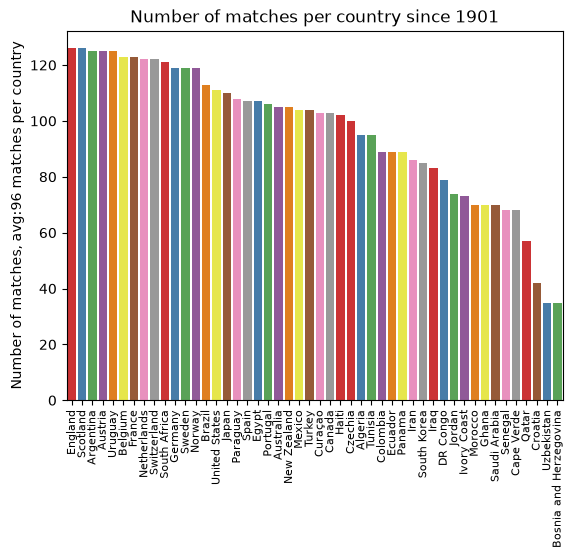

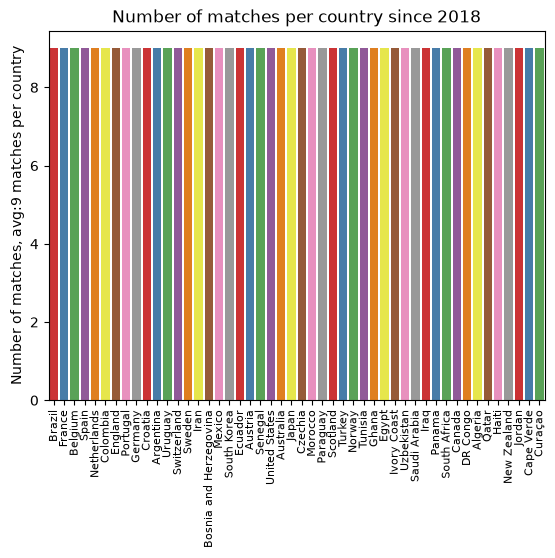

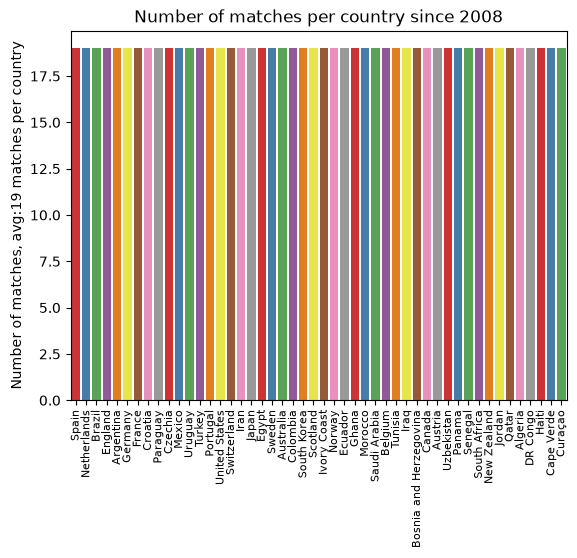

In [4]:
import math

wrc_2016_first_match_dt = pd.to_datetime("2018-06-14")
wrc_2008_first_match_dt = pd.to_datetime("2008-12-11")
import seaborn as sns
import matplotlib.pyplot as plt


def plot_matches_per_country(df: pd.DataFrame):
    count_plot = sns.countplot(x="country", data=df, palette="Set1", order=df["country"].value_counts().index,
                               hue="country")
    mean_matches = df.groupby("country").agg({"country": "count"}).mean()
    count_plot.set_title(f"Number of matches per country since {df['snapshot_date'].min().year}")
    count_plot.set_ylabel(f"Number of matches, avg:{math.floor(mean_matches['country'])} matches per country")
    count_plot.set_xlabel("")
    plt.xticks(rotation=90, fontsize=8)
    plt.show()


plot_matches_per_country(elo_df)
plot_matches_per_country(elo_df[elo_df["snapshot_date"] >= wrc_2016_first_match_dt])
plot_matches_per_country(elo_df[elo_df["snapshot_date"] >= wrc_2008_first_match_dt])




## 4. The data density problem

Within that window the snapshots are sparse: roughly ten data points per team every
eight years. That is nowhere near enough to fit a per-team model on its own, which
already hints that we will need the full match-by-match history rather than periodic
snapshots. Still, the per-group trajectories are a useful map of the landscape.


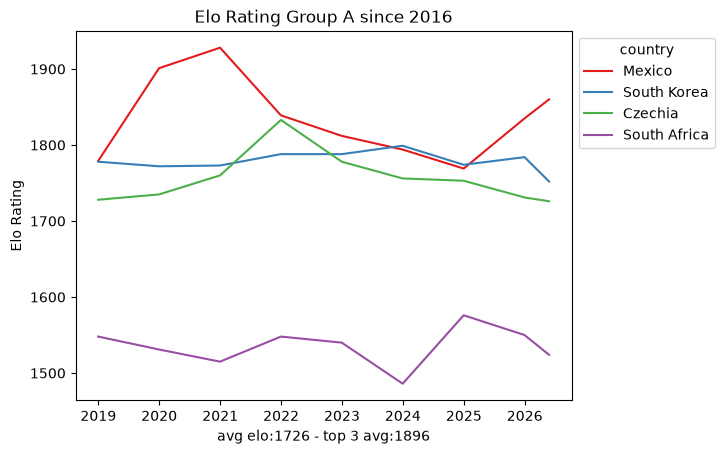

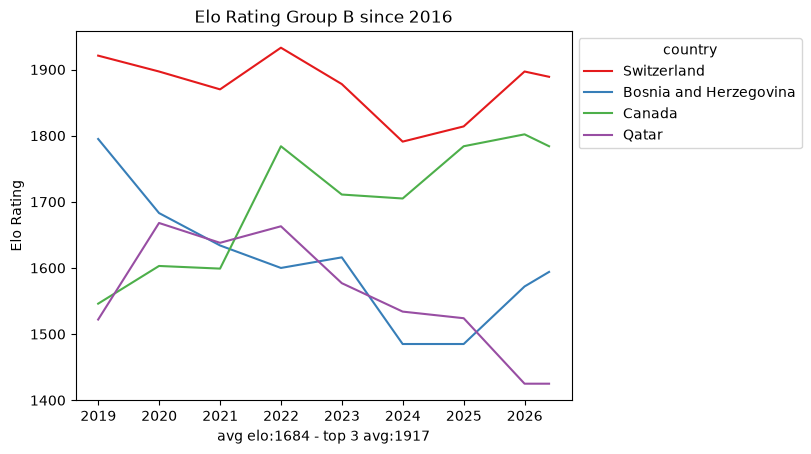

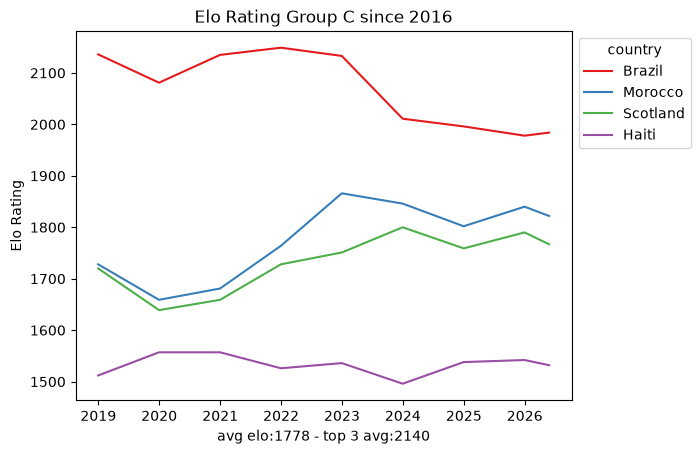

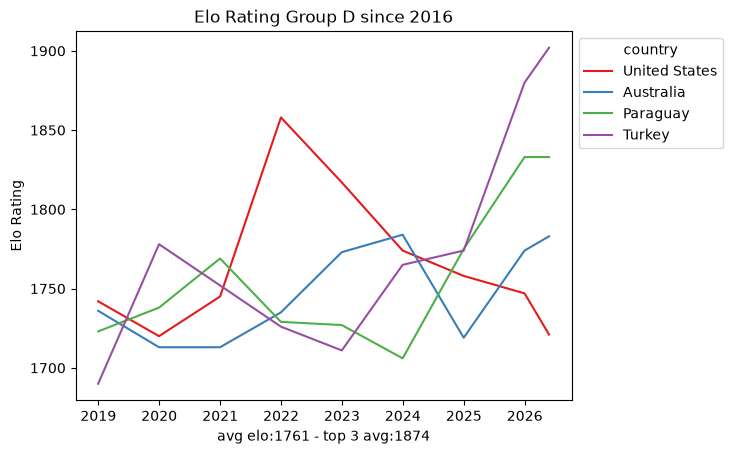

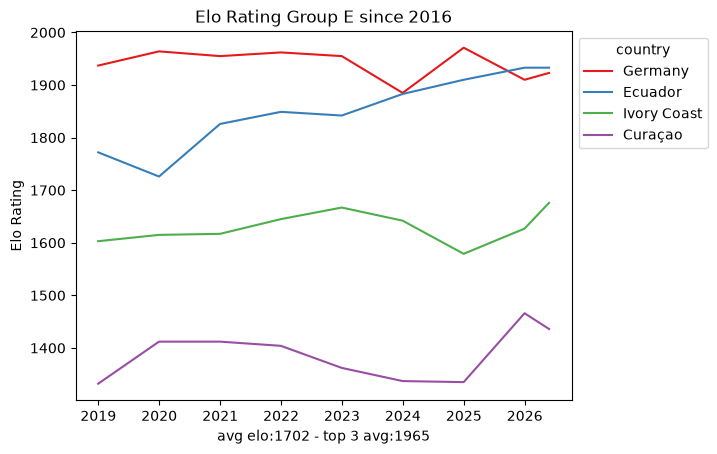

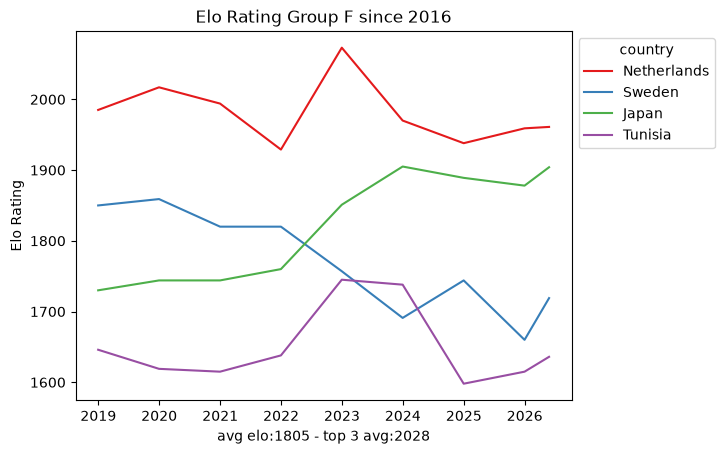

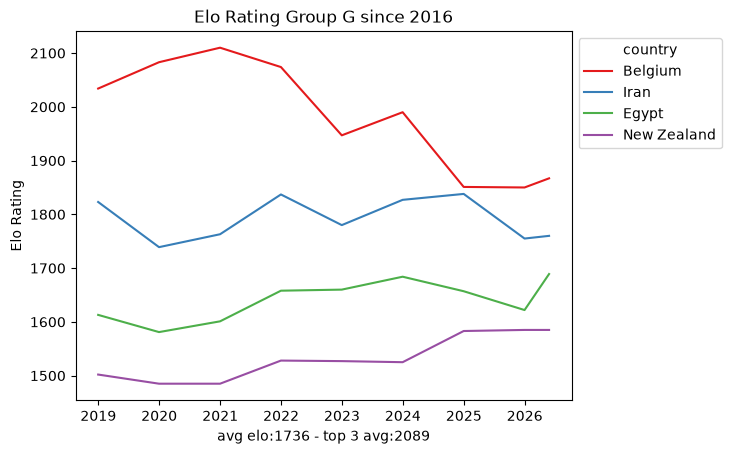

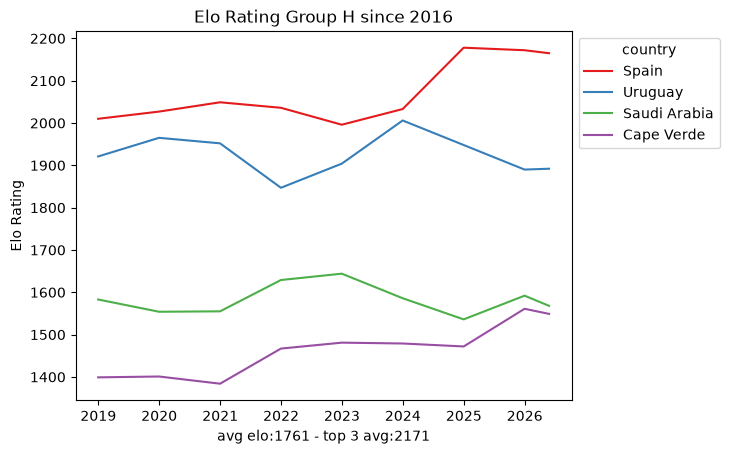

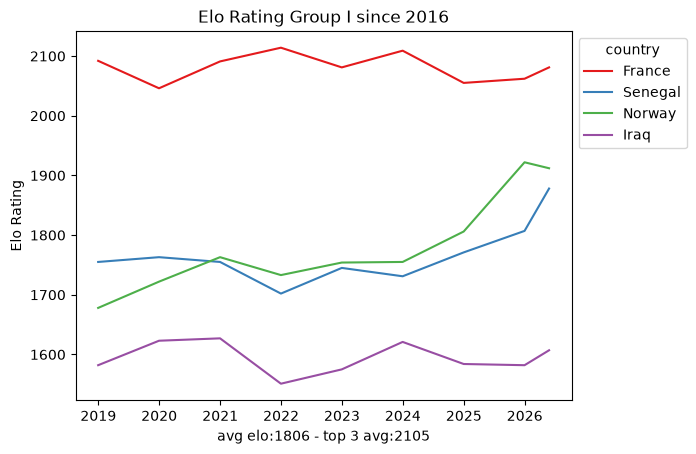

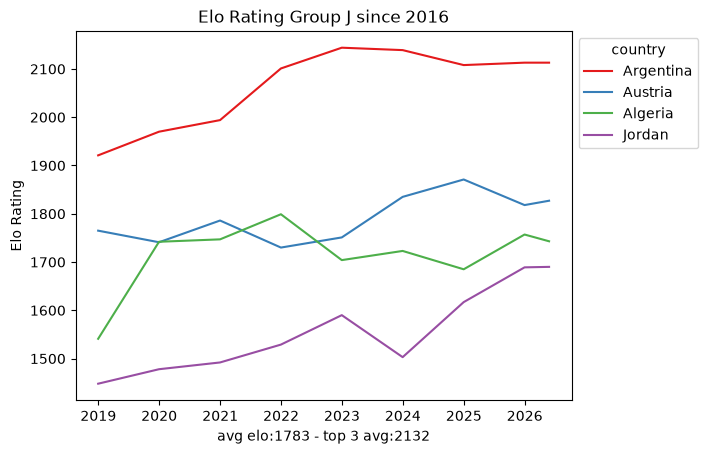

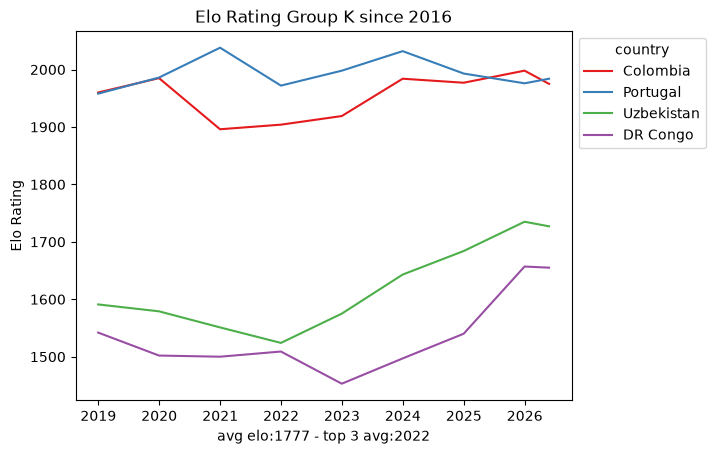

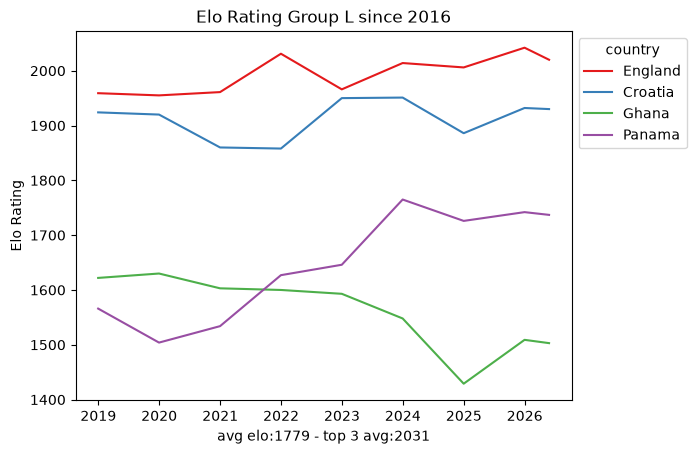

In [5]:
def plot_elo_per_group(df: pd.DataFrame, title: str = "Elo Rating per Group"):
    avg_elo = df.groupby("country").agg({"rating": "mean"}).mean()
    three_best_elo = df.sort_values(by="rating", ascending=False).head(3).groupby("country").agg({"rating": "mean"}).mean()
    filtered = df[['country', 'snapshot_date', 'rating']]
    ax = sns.lineplot(filtered, x="snapshot_date", y="rating", hue="country", palette="Set1")
    ax.set_xlabel(f"avg elo:{math.floor(avg_elo['rating'])} - top 3 avg:{math.floor(three_best_elo['rating'])}")
    ax.set_ylabel('Elo Rating')
    ax.set_title(title)
    # ax.legend(loc='upper left')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.show()


plot_elo_per_group(GROUP_A_all_stats[GROUP_A_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group A since 2016")
plot_elo_per_group(GROUP_B_all_stats[GROUP_B_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group B since 2016"
                   )
plot_elo_per_group(GROUP_C_all_stats[GROUP_C_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group C since 2016")
plot_elo_per_group(GROUP_D_all_stats[GROUP_D_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group D since 2016")
plot_elo_per_group(GROUP_E_all_stats[GROUP_E_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group E since 2016")
plot_elo_per_group(GROUP_F_all_stats[GROUP_F_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group F since 2016")
plot_elo_per_group(GROUP_G_all_stats[GROUP_G_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group G since 2016")
plot_elo_per_group(GROUP_H_all_stats[GROUP_H_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group H since 2016")
plot_elo_per_group(GROUP_I_all_stats[GROUP_I_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group I since 2016")
plot_elo_per_group(GROUP_J_all_stats[GROUP_J_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group J since 2016")
plot_elo_per_group(GROUP_K_all_stats[GROUP_K_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group K since 2016")
plot_elo_per_group(GROUP_L_all_stats[GROUP_L_all_stats["snapshot_date"] >= wrc_2016_first_match_dt],
                   "Elo Rating Group L since 2016")

## 5. Conclusion: a map, not a model

This dataset, by itself, cannot predict one team against another:

- **Too sparse.** A handful of snapshots per team is not training data.
- **No context.** A rating summarizes strength but says nothing about *how* a team
  wins: goals scored, where the match was played, or against what kind of opponent.
- **No matchups.** Two teams' ratings say who is favored, never what the score looks
  like.

What it is good for is a **map of the field**: which groups are lopsided, which are
tight, and who the favorites are. For the actual model we scraped the full
match-by-match Elo history of every qualified team from eloratings.net - that
exploration is in [EDA: Match Histories](EDA_elo_scrapper.ipynb).
